<a href="https://colab.research.google.com/github/kjamison/brainmontageplot/blob/main/brainmontageplot_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#may need to restart the runtime and run again after the first time this installs new packages
import sys
# if 'brainmontage' not in sys.modules:
!pip install git+https://github.com/kjamison/brainmontageplot.git

!pip install git+https://github.com/kjamison/brainmontageplot.git



import numpy as np
from brainmontage import create_montage_figure, save_image
from brainmontage.brainmontage import clear_cache
import matplotlib as mpl
from matplotlib import pyplot as plt


  Cloning https://github.com/kjamison/brainmontageplot.git to /private/var/folders/wd/8k1mgh3d4fl7g30hjg9j8pd80000gp/T/pip-req-build-1stdw8dc
  Running command git clone --filter=blob:none --quiet https://github.com/kjamison/brainmontageplot.git /private/var/folders/wd/8k1mgh3d4fl7g30hjg9j8pd80000gp/T/pip-req-build-1stdw8dc
  Resolved https://github.com/kjamison/brainmontageplot.git to commit 0bbc9a990fb9f96e086afe76fc8f3c33414049e8
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/kjamison/brainmontageplot.git to /private/var/folders/wd/8k1mgh3d4fl7g30hjg9j8pd80000gp/T/pip-req-build-qjoar7vp
  Running command git clone --filter=blob:none --quiet https://github.com/kjamison/brainmontageplot.git /private/var/folders/wd/8k1mgh3d4fl7g30hjg9j8pd80000gp/T/pip-req-build-qjoar7vp
  Resolved https://github.com/kjamison/brainmontageplot.git to commit 0bbc9a990fb9f96e086afe76fc8f3c33414049e8
  Preparing metadata (setup.py) ... done


In [3]:
%%time
#resting state alff
import nibabel as nib
ciftidata=nib.load("/Users/bsevchik/projects/alff_reho/group-alff_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii").get_fdata()[0,:]
# mask the date so that 0 is NaN
ciftidata[ciftidata == 0] = np.nan
low = np.nanpercentile(ciftidata, 0.5)
high = np.nanpercentile(ciftidata, 99.5)
clear_cache('facemap')
img=create_montage_figure(roivals=ciftidata,atlasname="cifti91k",colormap='turbo',
                          clim=[low,high], add_colorbar=False, upscale_factor=2,
                          viewnames=['lateral','medial'],face_mode='best',
                          outputimagefile='/Users/bsevchik/Documents/GitHub/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-alff_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii_montage.pdf')

plt.figure()
plt.imshow(img)
_=plt.axis('off')

[_add_readme_to_default_data_locations] Added README.md to /Users/bsevchik/miniforge3/lib/python3.12/site-packages/brainmontage/nilearn_data
[get_dataset_dir] Dataset created in /Users/bsevchik/miniforge3/lib/python3.12/site-packages/brainmontage/nilearn_data/fsaverage
[fetch_single_file] Downloading data from https://osf.io/svf8k/download ...
[fetch_single_file] Error while fetching file download; dataset fetching aborted.


SSLError: HTTPSConnectionPool(host='osf.io', port=443): Max retries exceeded with url: /svf8k/download (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)')))

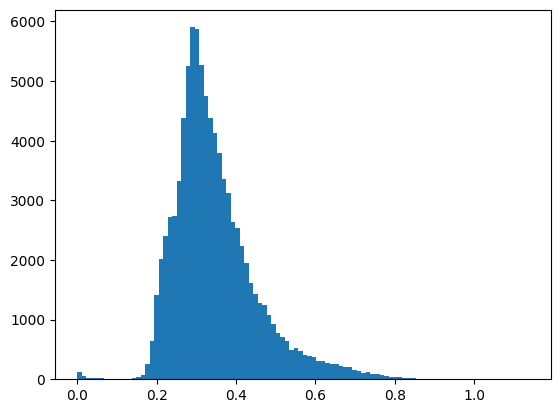

In [14]:
# plot density of ciftidata
plt.figure()
plt.hist(ciftidata, bins=100)
plt.show()


In [ ]:
# Define colormap and limits (same as montage)
cmap = plt.get_cmap('turbo')
low, high = np.nanpercentile(ciftidata, [0.5, 99.5])

# Create figure
fig, ax = plt.subplots(figsize=(0.4, 4))  # adjust size as needed

norm = mpl.colors.Normalize(vmin=low, vmax=high)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

# ✅ Force tick labels at min and max (and optional intermediate ticks)
cb.set_ticks([low, (low+high)/2, high])
cb.set_ticklabels([f"{low:.2f}", f"{(low+high)/2:.2f}", f"{high:.2f}"])

# Optional styling
cb.ax.tick_params(labelsize=10)
cb.set_label('ALFF', fontsize=12)

# Save as vector PDF
outpath = "/Users/bsevchik/Documents/GitHub/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-alff_task-rest_space-fsLR_den-91k_stat-mean_colorbar.pdf"
fig.savefig(outpath, format='pdf', bbox_inches='tight')

plt.close(fig)
print(f"Saved colorbar to: {outpath}")

Saved colorbar to: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-alff_task-rest_space-fsLR_den-91k_stat-mean_colorbar.pdf


Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-reho_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii_montage.pdf


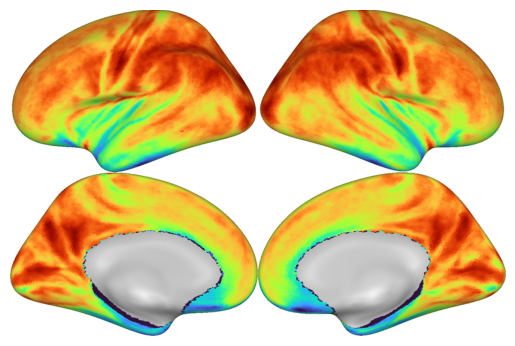

In [ ]:
ciftidata=nib.load("/Users/bsevchik/projects/alff_reho/group-reho_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii").get_fdata()[0,:]
# mask the date so that 0 is NaN
ciftidata[ciftidata == 0] = np.nan
low = 0.4
high = np.nanmax(ciftidata)
clear_cache('facemap')

img=create_montage_figure(roivals=ciftidata,atlasname="cifti91k",colormap="turbo",
                          clim=[low,high], add_colorbar=False, upscale_factor=2,
                          viewnames=['lateral','medial'],face_mode='best',
                          outputimagefile='/Users/bsevchik/Documents/GitHub/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-reho_task-rest_space-fsLR_den-91k_stat-mean.dscalar.nii_montage.pdf')
plt.figure()
plt.imshow(img)
_=plt.axis('off')

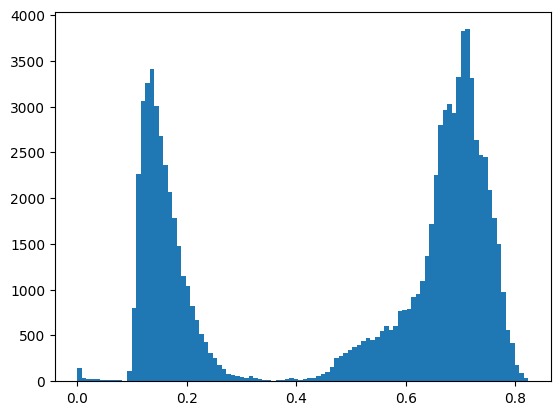

In [10]:
# plot density of ciftidata
plt.figure()
plt.hist(ciftidata, bins=100)
plt.show()


In [ ]:
# Define colormap and limits (same as montage)
cmap = plt.get_cmap('turbo')
low = 0.4
high = np.nanmax(ciftidata)

# Create figure
fig, ax = plt.subplots(figsize=(0.4, 4))  # adjust size as needed

norm = mpl.colors.Normalize(vmin=low, vmax=high)
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

# ✅ Force tick labels at min and max (and optional intermediate ticks)
cb.set_ticks([low, (low+high)/2, high])
cb.set_ticklabels([f"{low:.2f}", f"{(low+high)/2:.2f}", f"{high:.2f}"])

# Optional styling
cb.ax.tick_params(labelsize=10)
cb.set_label('ALFF', fontsize=12)

# Save as vector PDF
outpath = "/Users/bsevchik/Documents/GitHub/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-reho_task-rest_space-fsLR_den-91k_stat-mean_colorbar.pdf"
fig.savefig(outpath, format='pdf', bbox_inches='tight')

plt.close(fig)
print(f"Saved colorbar to: {outpath}")

Saved colorbar to: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/group-reho_task-rest_space-fsLR_den-91k_stat-mean_colorbar.pdf


In [3]:
%%time
# Loop over CIFTI/GIFTI .nii atlases and generate surface montages
# - Discovers: /Users/sps253/Desktop/atlases/*/*.nii
# - For each file, computes max label (ignoring NaNs) and sets roivals=1..max_label
# - Uses cifti91k atlas for fsLR 91k surfaces
# - Saves montage to same directory as .png file

import os, glob

atlas_roots = glob.glob('/Users/sps253/Desktop/atlases/*/*.nii')
out_path = '/Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots'
print(f"Found {len(atlas_roots)} .nii files")

# Output directory (next to each .nii)
for nii_path in atlas_roots:
    try:
        clear_cache('facemap')
        img_nii = nib.load(nii_path)
        data = img_nii.get_fdata()
        # Handle possible leading map dimension(s); flatten across maps if present
        if data.ndim >= 2:
            # CIFTI dlabel/dscalar usually [maps x vertices]; use max across all maps
            data_flat = np.asarray(data).reshape(-1)
        else:
            data_flat = np.asarray(data)
        # Exclude NaN and negative if labels are non-negative (keep 0 as background)
        finite_vals = data_flat[np.isfinite(data_flat)]
        if finite_vals.size == 0:
            print(f"Skip (no finite data): {nii_path}")
            continue
        max_label = int(np.nanmax(finite_vals))
        if max_label < 1:
            print(f"Skip (no positive labels): {nii_path}")
            continue
        roivals = np.arange(max_label) + 1

        # Derive output filename next to source
        base = os.path.splitext(os.path.basename(nii_path))[0]
        out_png = os.path.join(out_path, f"{base}_montage.png")

        img = create_montage_figure(
            roivals,
            atlasname='cifti91k',
            subparcfile=nii_path,
            viewnames=['lateral','medial'],
            surftype='infl',
            clim=[0, max_label],
            colormap='random',
            hemis=['lh'],
            face_mode='best',
            upscale_factor=2,
            add_colorbar=False,
            outputimagefile=out_png
        )
        # If not saved internally, also save here
        try:
            if img is not None:
                save_image(img, out_png)
        except Exception:
            pass

        print(f"Saved: {out_png}")
    except Exception as e:
        print(f"Error processing {nii_path}: {e}")

plt.close('all')


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Found 21 .nii files
Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache
Using random colormap with 360 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-Glasser_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-Glasser_space-fsLR_den-91k_dseg.dlabel_montage.png
Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache
Using random colormap with 956 entries.
[fetch_surf_fsaverage] Datas

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-4S1056Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-4S1056Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Using random colormap with 60 entries.
Error processing /Users/sps253/Desktop/atlases/atlas-HCP/atlas-HCP_space-fsLR_den-91k_dseg.dlabel.nii: Subparc file must match atlas dimensions. Found 31870, expected 91282.
Using random colormap with 60 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-HCP_space-fsLR_den-91k_padded_dseg.dlabel_montage.png
Saved: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-HCP_space-fsLR_den-91k_padded_dseg.dlabel_montage.png
Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontag

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-4S156Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Saved: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-4S156Parcels_space-fsLR_den-91k_dseg.dlabel_montage.png
Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache
Using random colormap with 333 entries.


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Error processing /Users/sps253/Desktop/atlases/atlas-Gordon/atlas-Gordon_space-fsLR_den-91k_dseg.dlabel.nii: Subparc file must match atlas dimensions. Found 64984, expected 91282.
Using random colormap with 333 entries.
[fetch_surf_fsaverage] Dataset found in /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/nilearn_data/fsaverage
Saved cached face-mapping file /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache/facemapping_cifti91k_fsaverage_5iter.mat
Saved /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-Gordon_space-fsLR_den-91k_padded_dseg.dlabel_montage.png
Saved: /Users/sps253/Documents/GIT/transdiagnostic_executive_function/neuroimaging_figures/surface_plots/atlas-Gordon_space-fsLR_den-91k_padded_dseg.dlabel_montage.png
Removed cache dir: /Users/sps253/miniforge3/envs/brainmontage/lib/python3.10/site-packages/brainmontage/atlas_cache
Using random